In [ ]:
# --- NORMALIZAÇÃO ----
import numpy as np

meanX = np.array([11.54549372, 12.4514907])
stdX = np.array([4.23449211, 3.9104502])
meanY = np.array([ 3.07519347, 46.57397573])
stdY = np.array([2.11485258, 3.02168235])

def std(x):
    return (x - meanX) / stdX
def destd(y_norm):
    return (y_norm * stdY) + meanY

In [ ]:
# --- MODELOS ---
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

# --------------------------------------------------------------------------
# RNN
# --------------------------------------------------------------------------

sess = ort.InferenceSession("model_JT_memory.onnx")

# Obter o nome da entrada (necessário para o ONNX)
input_name = sess.get_inputs()[0].name

def rnn_predict_onnx(u_window, session):

    # 1. Normalização da janela inteira
    u_norm = std(u_window)
    
    # 2. Reshape para (1, 6, 2) e cast para float32
    input_data = u_norm.reshape(1, 6, 2).astype(np.float32)
    
    # 3. Inferência ONNX
    outputs = session.run(None, {input_name: input_data})
    ypred_norm = outputs[0]
    
    # 4. Desnormalização da saída (previsão do próximo passo)
    return destd(ypred_norm.flatten())

# --------------------------------------------------------------------------
# Fenomenológico
# --------------------------------------------------------------------------
def jacketed_tank(x, t, u, m):
    L, T = x
    Fi, Fv = u

    # Importando parâmetros
    At  = m['At']
    k   = m['k']
    rho = m['rho']
    Cp  = m['Cp']
    lmb = m['lambda']
    Ti  = m['Ti']

    # Modelo simplificado: Fout = k * sqrt(h)
    f1 = (Fi - k * np.sqrt(L)) / At
    f2 = (rho * Fi * Cp * (Ti - T) + Fv * lmb) / (rho * At * L * Cp)
    f = [f1 , f2]
    
    return f

In [ ]:
# --- Função Objetivo do NMPC ---
import numpy as np

def fob_NMPC_RNN(du_flat, uk_1, Hp, Hc, ysp, q, r, memory_buffer_u, x0, nu, session): 

    du = du_flat.reshape((Hc, nu))
    cost = 0
    
    # Criamos uma cópia da janela real para simular o futuro
    current_window_u = memory_buffer_u.copy()
    u_atual = uk_1.copy()
    
    # Cálculo do Bias inicial (comparando a última predição com a realidade)
    y_pred_inicial = rnn_predict_onnx(memory_buffer_u, session)
    bias = x0 - y_pred_inicial

    for i in range(Hp):
        if i < Hc:
            u_atual = u_atual + du[i, :]
        
        # 1. Atualiza a janela: remove o mais antigo, adiciona o u_atual
        current_window_u = np.roll(current_window_u, -1, axis=0)
        current_window_u[-1, :] = u_atual
        
        # 2. Predição baseada na janela atualizada
        y_sim = rnn_predict_onnx(current_window_u, session) + bias
        
        # 3. Custo
        error = (y_sim - ysp).flatten()
        cost += error @ np.diag(q) @ error
        
        if i < Hc:
            cost += du[i, :] @ np.diag(r) @ du[i, :]  
    return cost

In [100]:
import numpy as np

# --------------------------------------------------------------------------
# Parâmetros e Configurações
# --------------------------------------------------------------------------
modelo = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}
nsim = 200
Hp, Hc = 10, 2
q = np.array([10, 10])
r = np.array([0.1, 0.1])
Ts = 0.1
nu, ny = 2, 2

# Restrições
umin = np.array([5, 5])
umax = np.array([20, 30])
dumax = np.array([1, 2])

# Condições iniciais
uk_1 = np.array([10.0, 10.0])
x0 = np.array([2.0408, 45.4])
x0m = x0.copy()
du0 = np.zeros(Hc * nu)

# Armazenamento de dados
history = {'yp': [], 'uk': [], 'sp': [], 'J': [], 'tcalc': []}

In [101]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import odeint
import time
    
# --------------------------------------------------------------------------
# Loop de Simulação
# --------------------------------------------------------------------------
# Ajuste de Entrada da RNN
memory_buffer_u = np.tile(uk_1, (6, 1))

for k in range(nsim):
    if(k<30):
        ysp = np.array([3.0, 50.0])
    if(30 < k < 100):
        ysp = np.array([2.5, 47.0])
    if(k>100):
        ysp = np.array([4.0, 48.0])

    #memory_buffer = np.roll(memory_buffer, -1, axis=0)
    #memory_buffer[-1, :] = ysp # Adiciona a medição real ao histórico
    
    # ----------- Restrições para o otimizador -------------
    bounds = [(-dumax[i%nu], dumax[i%nu]) for i in range(Hc*nu)]
    constraints = {
    'type': 'ineq', 
    'fun': lambda du, uk_1, umin, umax: np.array([
        # Isso substitui o Bin = @(uk_1) [repmat(umax...)]
        *[(umax - (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0))).flatten() for i in range(Hc)],
        *[( (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0)) - umin).flatten() for i in range(Hc)]
    ]).flatten(),
    'args': (uk_1, umin, umax)
    }

    options = {
        'eps': 1e-2,
        'ftol': 1e-2,
        'maxiter': 5
    }

    start_time = time.time() # 1 Marca o tempo de início
    res = minimize(fob_NMPC_RNN,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, memory_buffer_u, x0, nu, sess),
                   method='SLSQP', 
                   bounds=bounds,
                   constraints=constraints,
                   options=options
                   )
    history['tcalc'].append(time.time() - start_time) # 2 Calcula a diferença

    du_opt = res.x.reshape((Hc, nu))
    uk_atual = uk_1 + du_opt[0, :]
    
    # Atualiza o histórico real para a próxima iteração do NMPC
    memory_buffer_u = np.roll(memory_buffer_u, -1, axis=0)
    memory_buffer_u[-1, :] = uk_atual

    # Planta (Simulação real)
    mult = 1 if k < 80 else 1.1
    u_planta = uk_atual * mult
    x_next_p = odeint(jacketed_tank, x0, [0, Ts], args=(u_planta, modelo))[-1, :]

    # Modelo (Simulação interna do controlador)
    x_next_m = rnn_predict_onnx(memory_buffer_u, sess)

    # Atualização
    history['yp'].append(x_next_p)
    history['uk'].append(uk_atual)
    history['sp'].append(ysp)
    history['J'].append(res.fun)
    
    x0, x0m, uk_1 = x_next_p, x_next_m, uk_atual
    du0 = np.concatenate([du_opt[1:], np.zeros((1, nu))]).flatten()


Tempo Máximo[s] =  0.31459665298461914 
Tempo Médio[s] =  0.07132082104682923 
Tempo Total[s] =  14.264164209365845


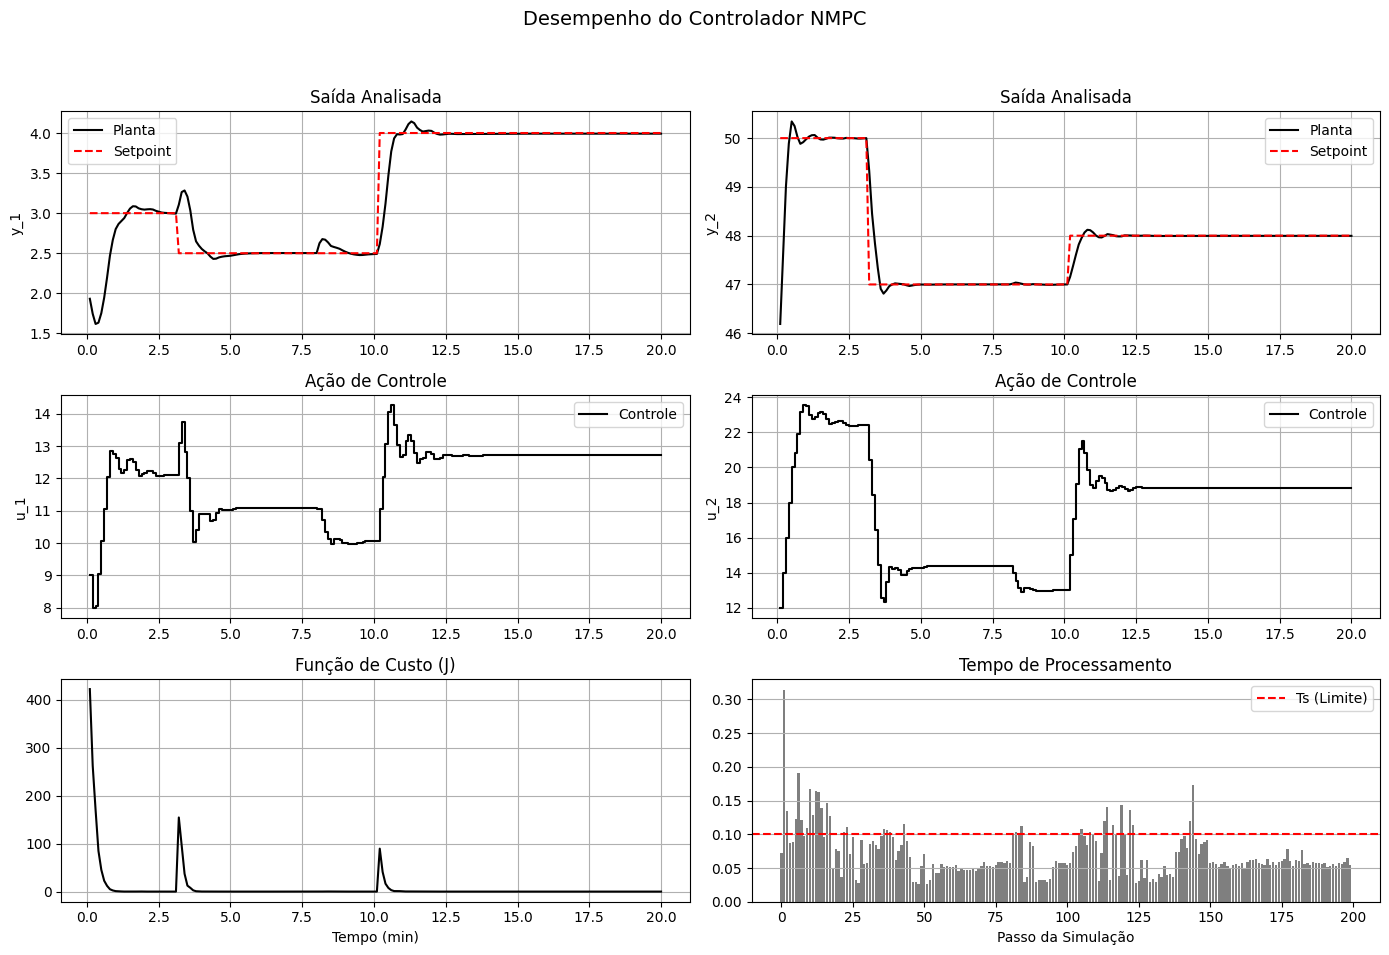

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Gráficos
# --------------------------------------------------------------------------
history['yp'] = np.array(history['yp'])
history['uk'] = np.array(history['uk'])
history['sp'] = np.array(history['sp'])
history['cost'] = np.array(history['J'])
t_axis = np.linspace(Ts, nsim*Ts, nsim)

tempo_medio = np.mean(history['tcalc'])
tempo_max = np.max(history['tcalc'])
tempo_sum = np.sum(history['tcalc'])
print(f'Tempo Máximo[s] = ', tempo_max, '\nTempo Médio[s] = ', tempo_medio, '\nTempo Total[s] = ', tempo_sum)

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Desempenho do Controlador NMPC', fontsize=14)

# --- 1. SAÍDAS (y) ---
for i in range(ny):
    axs[0, i].plot(t_axis, history['yp'][:, i], 'k', label='Planta')
    axs[0, i].plot(t_axis, history['sp'][:, i], 'r--', label='Setpoint')
    axs[0, i].set_title(f'Saída Analisada')
    axs[0, i].set_ylabel(f'y_{i+1}')
    axs[0, i].grid(True)
    axs[0, i].legend()

# --- 2. ENTRADAS (u) ---
for i in range(nu):
    axs[1, i].step(t_axis, history['uk'][:, i], 'k', label='Controle', where='post')
    axs[1, i].set_title(f'Ação de Controle')
    axs[1, i].set_ylabel(f'u_{i+1}')
    axs[1, i].grid(True)
    axs[1, i].legend()

# --- 3. DESEMPENHO (Custo e Tempo) ---
# Gráfico de Custo
axs[2, 0].plot(t_axis, history['J'], 'k', label= 'Custo', linewidth=1.5)
axs[2, 0].set_title('Função de Custo (J)')
axs[2, 0].set_xlabel('Tempo (min)')
axs[2, 0].grid(True)

# Gráfico de Tempo de Cálculo
axs[2, 1].bar(range(nsim), history['tcalc'], color='k', alpha=0.5)
axs[2, 1].axhline(y=Ts, color='r', linestyle='--', label='Ts (Limite)')
axs[2, 1].set_title('Tempo de Processamento')
axs[2, 1].set_xlabel('Passo da Simulação')
axs[2, 1].legend()
axs[2, 1].grid(axis='y')

# Ajuste fino para não sobrepor títulos e eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()